In [1]:
# Cell 1 — Check GPU
import torch, os, sys
print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
# Cell 2 — Install dependencies
import sys

!{sys.executable} -m pip -q install --upgrade pip
!{sys.executable} -m pip -q install ultralytics opencv-python-headless pyyaml matplotlib pandas transformers accelerate timm huggingface_hub

print("Install complete. If DINO import fails, restart runtime once and rerun from Cell 1.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.7 MB/s eta 0:00:00
Install complete. If DINO import fails, restart runtime once and rerun from Cell 1.


In [3]:
# Cell 3 — Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Cell 4 — Configuration
from pathlib import Path

try:
    from google.colab import userdata
    from huggingface_hub import login
    hf_token = userdata.get("HF_TOKEN")
    if hf_token:
        login(token=hf_token)
except Exception as e:
    print("HF login skipped:", e)

VIDEO_DIR = Path('/content/drive/MyDrive/CS591 Digital Image Processing/Videos')
OUTPUT_DIR = Path('/content/poster_flyer_yolo_dataset')

TARGET_COUNT = 100
SAMPLE_EVERY = 15
MIN_MOTION = 8.0
MIN_SHARPNESS = 60.0
MAX_WIDTH = 1280
DINO_MODEL_ID = 'IDEA-Research/grounding-dino-tiny'
DINO_TEXT_PROMPT = 'poster. flyer.'
DINO_BOX_THRESHOLD = 0.25
DINO_TEXT_THRESHOLD = 0.25
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
SEED = 42

YOLO_WORLD_WEIGHTS = 'yolov8s-world.pt'
EPOCHS = 100
IMG_SIZE = 640
BATCH = 8
WORKERS = 2
PROJECT = '/content/runs_yolo_world'
RUN_NAME = 'poster_flyer_finetune'

VIDEO_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('VIDEO_DIR:', VIDEO_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


VIDEO_DIR: /content/drive/MyDrive/CS591 Digital Image Processing/Videos
OUTPUT_DIR: /content/poster_flyer_yolo_dataset


In [5]:
# Cell 5 — Find input videos
VIDEO_EXTS = {'.mp4', '.mov', '.avi', '.mkv', '.m4v', '.webm'}
video_paths = sorted([p for p in VIDEO_DIR.rglob('*') if p.suffix.lower() in VIDEO_EXTS])

print(f'Found {len(video_paths)} video(s):')
for p in video_paths:
    print(' -', p)

assert len(video_paths) > 0, f'No videos found in {VIDEO_DIR}. Upload videos or change VIDEO_DIR.'


Found 7 video(s):
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260420_114406.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260420_114525.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260420_114740.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260422_060000.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260422_060400.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260422_060700.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260422_061400.mp4


In [6]:
# Cell 6 — Dataset generation code: videos → frames → DINO boxes → YOLO labels → data.yaml
import os
import cv2
import yaml
import shutil
import random
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection


def laplacian_sharpness(frame_bgr):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def frame_difference_score(frame_a, frame_b, resize_width=320):
    if frame_a is None or frame_b is None:
        return float('inf')

    def resize(frame):
        h, w = frame.shape[:2]
        scale = resize_width / w
        return cv2.resize(frame, (resize_width, int(h * scale)))

    a = resize(frame_a)
    b = resize(frame_b)

    if a.shape != b.shape:
        b = cv2.resize(b, (a.shape[1], a.shape[0]))

    return float(np.mean(cv2.absdiff(a, b)))


def xyxy_to_yolo(box, img_w, img_h):
    x1, y1, x2, y2 = box

    x1 = max(0, min(float(x1), img_w - 1))
    y1 = max(0, min(float(y1), img_h - 1))
    x2 = max(0, min(float(x2), img_w - 1))
    y2 = max(0, min(float(y2), img_h - 1))

    bw = x2 - x1
    bh = y2 - y1

    if bw <= 1 or bh <= 1:
        return None

    x_center = x1 + bw / 2
    y_center = y1 + bh / 2

    return x_center / img_w, y_center / img_h, bw / img_w, bh / img_h


def write_yolo_label(label_path, boxes, img_w, img_h, class_id=0):
    lines = []

    for box in boxes:
        yolo_box = xyxy_to_yolo(box, img_w, img_h)
        if yolo_box is None:
            continue

        x, y, w, h = yolo_box
        lines.append(f'{class_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}')

    with open(label_path, 'w') as f:
        f.write('\n'.join(lines))


def _to_numpy(x):
    if x is None:
        return None

    if isinstance(x, torch.Tensor):
        if x.dtype in (torch.bfloat16, torch.float16):
            x = x.float()
        return x.detach().cpu().numpy()

    if hasattr(x, 'tensor'):
        return _to_numpy(x.tensor)

    arr = np.asarray(x)

    if arr.dtype == np.dtype('O'):
        return arr

    return arr


def extract_boxes_from_dino_result(result, box_threshold=0.25):
    boxes = result.get('boxes', [])
    scores = result.get('scores', None)

    boxes = _to_numpy(boxes)
    scores = _to_numpy(scores) if scores is not None else None

    if boxes is None or len(boxes) == 0:
        return []

    boxes = np.asarray(boxes).reshape(-1, 4)
    if scores is not None:
        scores = np.asarray(scores).reshape(-1)

    final_boxes = []
    for i, box in enumerate(boxes):
        score = float(scores[i]) if scores is not None and i < len(scores) else 1.0
        if score < box_threshold:
            continue

        x1, y1, x2, y2 = [float(v) for v in box]
        if x2 <= x1 or y2 <= y1:
            continue

        final_boxes.append([x1, y1, x2, y2])

    return final_boxes


def load_dino(model_id='IDEA-Research/grounding-dino-tiny'):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Loading DINO on {device}...')
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)
    model.eval()
    return processor, model, device


def post_process_dino(processor, outputs, inputs, image, box_threshold, text_threshold):
    target_sizes = torch.tensor([image.size[::-1]], device=outputs.logits.device)
    input_ids = getattr(inputs, 'input_ids', None)
    method = processor.post_process_grounded_object_detection

    attempts = []
    if input_ids is not None:
        attempts.append(((), {'input_ids': input_ids, 'threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
        attempts.append(((input_ids,), {'threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
    attempts.append(((), {'threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
    if input_ids is not None:
        attempts.append(((), {'input_ids': input_ids, 'box_threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
        attempts.append(((input_ids,), {'box_threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
    attempts.append(((), {'box_threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))

    last_error = None
    for args, kwargs in attempts:
        try:
            return method(outputs, *args, **kwargs)
        except TypeError as e:
            last_error = e

    raise last_error


def run_dino_on_image(processor, model, device, image_path, prompt, box_threshold, text_threshold):
    image = Image.open(image_path).convert('RGB')
    inputs = processor(images=image, text=prompt, return_tensors='pt').to(device)

    with torch.inference_mode():
        outputs = model(**inputs)

    results = post_process_dino(
        processor=processor,
        outputs=outputs,
        inputs=inputs,
        image=image,
        box_threshold=box_threshold,
        text_threshold=text_threshold,
    )

    return extract_boxes_from_dino_result(results[0], box_threshold=box_threshold)


def extract_candidate_frames(
    video_paths,
    temp_frame_dir,
    target_count=200,
    sample_every=15,
    min_motion=8.0,
    min_sharpness=60.0,
    max_width=1280,
):
    temp_frame_dir = Path(temp_frame_dir)
    temp_frame_dir.mkdir(parents=True, exist_ok=True)

    candidates = []

    for video_idx, video_path in enumerate(video_paths):
        video_path = Path(video_path)
        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            print(f'Warning: could not open {video_path}')
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f'Reading {video_path.name}: {total_frames} frames')

        prev_kept_frame = None
        frame_idx = 0

        pbar = tqdm(total=total_frames if total_frames > 0 else None, desc=video_path.name)
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            if frame_idx % sample_every == 0:
                sharpness = laplacian_sharpness(frame)
                motion = frame_difference_score(prev_kept_frame, frame)

                if sharpness >= min_sharpness and motion >= min_motion:
                    h, w = frame.shape[:2]

                    if w > max_width:
                        scale = max_width / w
                        new_w = max_width
                        new_h = int(h * scale)
                        frame = cv2.resize(frame, (new_w, new_h))

                    out_name = f'video{video_idx:03d}_frame{frame_idx:06d}.jpg'
                    out_path = temp_frame_dir / out_name
                    cv2.imwrite(str(out_path), frame)

                    candidates.append({
                        'path': out_path,
                        'sharpness': sharpness,
                        'motion': motion,
                        'video': video_path.name,
                        'frame_idx': frame_idx,
                    })

                    prev_kept_frame = frame.copy()

            frame_idx += 1
            pbar.update(1)
        pbar.close()
        cap.release()

    if not candidates:
        raise RuntimeError('No candidate frames found. Lower MIN_SHARPNESS or MIN_MOTION.')

    candidates.sort(key=lambda x: (x['sharpness'] * 0.7 + x['motion'] * 10.0), reverse=True)
    selected = candidates[:target_count]

    print(f'Selected {len(selected)} frames from {len(candidates)} candidates.')
    return selected


def make_dataset_dirs(output_dir, clear_existing=True):
    output_dir = Path(output_dir)

    if clear_existing and output_dir.exists():
        for child in ['images', 'labels', '_candidate_frames', 'data.yaml']:
            p = output_dir / child
            if p.is_dir():
                shutil.rmtree(p)
            elif p.exists():
                p.unlink()

    for split in ['train', 'val', 'test']:
        (output_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
        (output_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

    return output_dir


def split_items(items, train_ratio=0.8, val_ratio=0.1, seed=42):
    random.seed(seed)
    items = items[:]
    random.shuffle(items)

    n = len(items)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    return {
        'train': items[:n_train],
        'val': items[n_train:n_train + n_val],
        'test': items[n_train + n_val:],
    }


def create_data_yaml(output_dir, class_name='poster_flyer'):
    data = {
        'path': str(Path(output_dir).resolve()),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'names': {0: class_name},
    }

    yaml_path = Path(output_dir) / 'data.yaml'
    with open(yaml_path, 'w') as f:
        yaml.safe_dump(data, f, sort_keys=False)

    print(f'Wrote {yaml_path}')
    return yaml_path


def generate_yolo_dataset(
    video_paths,
    output_dir,
    target_count=200,
    sample_every=15,
    min_motion=8.0,
    min_sharpness=60.0,
    max_width=1280,
    prompt='poster. flyer.',
    box_threshold=0.25,
    text_threshold=0.25,
    model_id='IDEA-Research/grounding-dino-tiny',
    train_ratio=0.8,
    val_ratio=0.1,
    seed=42,
    clear_existing=True,
):
    output_dir = make_dataset_dirs(output_dir, clear_existing=clear_existing)
    temp_frame_dir = output_dir / '_candidate_frames'

    selected_frames = extract_candidate_frames(
        video_paths=video_paths,
        temp_frame_dir=temp_frame_dir,
        target_count=target_count,
        sample_every=sample_every,
        min_motion=min_motion,
        min_sharpness=min_sharpness,
        max_width=max_width,
    )

    splits = split_items(selected_frames, train_ratio, val_ratio, seed)
    processor, model, device = load_dino(model_id=model_id)

    kept_count = 0
    skipped_no_boxes = 0
    split_counts = {}

    for split, items in splits.items():
        print(f'\nProcessing split: {split} ({len(items)} candidate images)')
        split_kept = 0

        for item in tqdm(items, desc=f'DINO {split}'):
            src_img_path = Path(item['path'])
            boxes = run_dino_on_image(
                processor=processor,
                model=model,
                device=device,
                image_path=src_img_path,
                prompt=prompt,
                box_threshold=box_threshold,
                text_threshold=text_threshold,
            )

            if len(boxes) == 0:
                skipped_no_boxes += 1
                continue

            img = cv2.imread(str(src_img_path))
            if img is None:
                print(f'Warning: could not read {src_img_path}')
                continue

            img_h, img_w = img.shape[:2]
            dst_img_path = output_dir / 'images' / split / src_img_path.name
            dst_label_path = output_dir / 'labels' / split / src_img_path.with_suffix('.txt').name

            shutil.copy2(src_img_path, dst_img_path)
            write_yolo_label(dst_label_path, boxes, img_w=img_w, img_h=img_h, class_id=0)

            kept_count += 1
            split_kept += 1

        split_counts[split] = split_kept

    yaml_path = create_data_yaml(output_dir)

    print('\nDone.')
    print('Images kept with labels:', kept_count)
    print('Skipped because DINO found no boxes:', skipped_no_boxes)
    print('Split counts:', split_counts)
    print('Dataset directory:', output_dir)
    print('YOLO data file:', yaml_path)

    del processor, model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return yaml_path, split_counts


In [7]:
# Cell 7 — Generate the YOLO dataset
DATA_YAML, split_counts = generate_yolo_dataset(
    video_paths=video_paths,
    output_dir=OUTPUT_DIR,
    target_count=TARGET_COUNT,
    sample_every=SAMPLE_EVERY,
    min_motion=MIN_MOTION,
    min_sharpness=MIN_SHARPNESS,
    max_width=MAX_WIDTH,
    prompt=DINO_TEXT_PROMPT,
    box_threshold=DINO_BOX_THRESHOLD,
    text_threshold=DINO_TEXT_THRESHOLD,
    model_id=DINO_MODEL_ID,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SEED,
    clear_existing=True,
)

print('DATA_YAML =', DATA_YAML)
print('split_counts =', split_counts)


Reading 20260420_114406.mp4: 399 frames


20260420_114406.mp4:   0%|          | 0/399 [00:00<?, ?it/s]

Reading 20260420_114525.mp4: 208 frames


20260420_114525.mp4:   0%|          | 0/208 [00:00<?, ?it/s]

Reading 20260420_114740.mp4: 646 frames


...


Processing split: val (10 candidate images)


DINO val:   0%|          | 0/10 [00:00<?, ?it/s]


Processing split: test (10 candidate images)


DINO test:   0%|          | 0/10 [00:00<?, ?it/s]

Wrote /content/poster_flyer_yolo_dataset/data.yaml

Done.
Images kept with labels: 100
Skipped because DINO found no boxes: 0
Split counts: {'train': 80, 'val': 10, 'test': 10}
Dataset directory: /content/poster_flyer_yolo_dataset
YOLO data file: /content/poster_flyer_yolo_dataset/data.yaml
DATA_YAML = /content/poster_flyer_yolo_dataset/data.yaml
split_counts = {'train': 80, 'val': 10, 'test': 10}


In [8]:
# Cell 8 — Inspect generated dataset counts
from pathlib import Path

for split in ['train', 'val', 'test']:
    n_img = len(list((OUTPUT_DIR / 'images' / split).glob('*.jpg')))
    n_lbl = len(list((OUTPUT_DIR / 'labels' / split).glob('*.txt')))
    print(f'{split:5s}: {n_img:4d} images | {n_lbl:4d} labels')

print('data.yaml contents:')
print(Path(DATA_YAML).read_text())


train:   80 images |   80 labels
val  :   10 images |   10 labels
test :   10 images |   10 labels
data.yaml contents:
path: /content/poster_flyer_yolo_dataset
train: images/train
val: images/val
test: images/test
names:
  0: poster_flyer



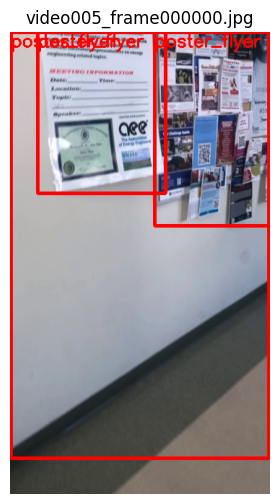

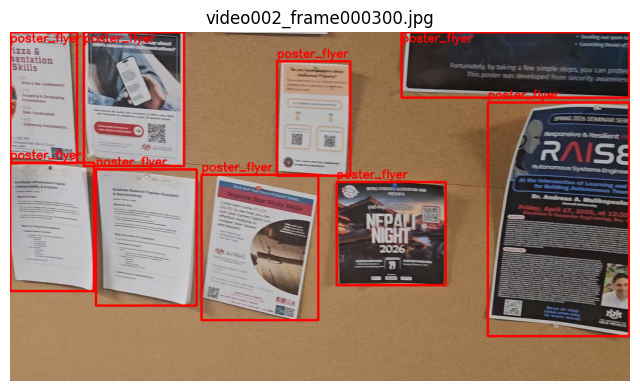

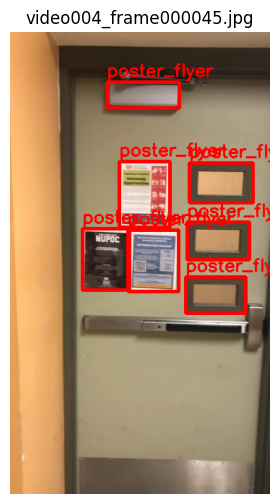

In [9]:
# Cell 9 — Preview a few pseudo-labels
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


def draw_yolo_labels(image_path, label_path):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if Path(label_path).exists():
        for line in Path(label_path).read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, xc, yc, bw, bh = parts
            xc, yc, bw, bh = map(float, [xc, yc, bw, bh])
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cv2.putText(img, 'poster_flyer', (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    return img


sample_images = list((OUTPUT_DIR / 'images' / 'train').glob('*.jpg'))
assert sample_images, 'No train images found.'

for image_path in random.sample(sample_images, k=min(3, len(sample_images))):
    label_path = OUTPUT_DIR / 'labels' / 'train' / image_path.with_suffix('.txt').name
    img = draw_yolo_labels(image_path, label_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(image_path.name)
    plt.show()


In [10]:
# Cell 10 — Train / fine-tune pretrained YOLO-World
from ultralytics import YOLOWorld
import torch

assert Path(DATA_YAML).exists(), f'Missing data.yaml: {DATA_YAML}'

model = YOLOWorld(YOLO_WORLD_WEIGHTS)

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=0 if torch.cuda.is_available() else 'cpu',
    workers=WORKERS,
    project=PROJECT,
    name=RUN_NAME,
    pretrained=True,
)

BEST_MODEL_PATH = Path(PROJECT) / RUN_NAME / 'weights' / 'best.pt'
print('Best model:', BEST_MODEL_PATH)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/poster_flyer_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, 

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 129MiB/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2413.0±1340.6 MB/s, size: 100.4 KB)
val: Scanning /content/poster_flyer_yolo_dataset/labels/val... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 702.0it/s 0.0s
val: New cache created: /content/poster_flyer_yolo_dataset/labels/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 67 weight(decay=0.0), 79 weight(decay=0.0005), 88 bias(decay=0.0)
Plotting labels to /content/runs_yolo_world/poster_flyer_finetune/labels.jpg... 
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/runs_yolo_world/poster_flyer_finetune
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      2.59G     0.9035      2.694      1.159        152        640: 20% ━━────────── 2/10 

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      2.65G     0.8742      2.759      1.148        161        640: 100% ━━━━━━━━━━━━ 10/10 9.2it/s 1.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.4it/s 0.4s
                   all         10         92      0.776      0.674      0.777      0.662

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      2.76G     0.5919      1.526      1.023        216        640: 20% ━━────────── 2/10 5.1it/s 0.1s<1.6s

...

     98/100      2.78G     0.1799     0.1789     0.7753         70        640: 100% ━━━━━━━━━━━━ 10/10 27.8it/s 0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 47.4it/s 0.0s
                   all         10         92      0.841      0.921      0.936      0.892

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/100      2.78G     0.1712     0.1731     0.7756        103        640: 50% ━━━━━━────── 5/10 12.8it/s 0.2s<0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     99/100      2.78G     0.1902     0.1811     0.7801         93        640: 100% ━━━━━━━━━━━━ 10/10 28.3it/s 0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 47.0it/s 0.0s
                   all         10         92      0.836      0.945      0.936      0.895

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/100      2.78G     0.1795      0.177     0.7893         61        640: 50% ━━━━━━────── 5/10 12.1it/s 0.2s<0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    100/100      2.78G      0.181     0.1761      0.792         77        640: 100% ━━━━━━━━━━━━ 10/10 28.2it/s 0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 46.7it/s 0.0s
                   all         10         92      0.844      0.942      0.936      0.897

100 epochs completed in 0.018 hours.
Optimizer stripped from /content/runs_yolo_world/poster_flyer_finetune/weights/last.pt, 27.1MB
Optimizer stripped from /content/runs_yolo_world/poster_flyer_finetune/weights/best.pt, 27.1MB

Validating /content/runs_yolo_world/poster_flyer_finetune/weights/best.pt...
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLOv8s-world summary (fused): 101 layers, 13,372,904 parameters, 0 gradients, 35.9 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 47.8it/s 0.0s
                   all    

In [11]:
# Cell 11 — Validate best YOLO-World model
from ultralytics import YOLOWorld

best_model = YOLOWorld(str(BEST_MODEL_PATH))
metrics = best_model.val(data=str(DATA_YAML), imgsz=IMG_SIZE)
print(metrics)


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLOv8s-world summary (fused): 101 layers, 13,372,904 parameters, 0 gradients, 35.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5879.6±3704.4 MB/s, size: 170.8 KB)
val: Scanning /content/poster_flyer_yolo_dataset/labels/val.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 6.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 13.6it/s 0.1s
                   all         10         92      0.859      0.946      0.944      0.909
Speed: 0.3ms preprocess, 4.2ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d546fb0de50>


In [12]:
# Cell 12 — Run inference on test images
from ultralytics import YOLOWorld

best_model = YOLOWorld(str(BEST_MODEL_PATH))

test_source = OUTPUT_DIR / 'images' / 'test'
if not any(test_source.glob('*.jpg')):
    test_source = OUTPUT_DIR / 'images' / 'val'

pred_results = best_model.predict(
    source=str(test_source),
    imgsz=IMG_SIZE,
    conf=0.25,
    save=True,
    project=PROJECT,
    name=RUN_NAME + '_predictions',
)

print('Predictions saved under:', Path(PROJECT) / (RUN_NAME + '_predictions'))



image 1/10 /content/poster_flyer_yolo_dataset/images/test/video000_frame000225.jpg: 384x640 6 poster_flyers, 18.1ms
image 2/10 /content/poster_flyer_yolo_dataset/images/test/video000_frame000240.jpg: 384x640 6 poster_flyers, 4.0ms
image 3/10 /content/poster_flyer_yolo_dataset/images/test/video000_frame000345.jpg: 384x640 11 poster_flyers, 3.6ms
image 4/10 /content/poster_flyer_yolo_dataset/images/test/video001_frame000015.jpg: 384x640 16 poster_flyers, 3.6ms
image 5/10 /content/poster_flyer_yolo_dataset/images/test/video003_frame000000.jpg: 640x384 5 poster_flyers, 16.5ms
image 6/10 /content/poster_flyer_yolo_dataset/images/test/video003_frame000075.jpg: 640x384 12 poster_flyers, 3.4ms
image 7/10 /content/poster_flyer_yolo_dataset/images/test/video003_frame000135.jpg: 640x384 10 poster_flyers, 3.4ms
image 8/10 /content/poster_flyer_yolo_dataset/images/test/video003_frame000210.jpg: 640x384 12 poster_flyers, 3.4ms
image 9/10 /content/poster_flyer_yolo_dataset/images/test/video003_frame

In [13]:
# Cell 13 — Zip dataset and best model for download
from pathlib import Path
from google.colab import files
import zipfile

zip_path = Path('/content/poster_flyer_yolo_outputs.zip')
if zip_path.exists():
    zip_path.unlink()

best_model_path = Path('/content/runs_yolo_world/poster_flyer_finetune/weights/best.pt')
assert best_model_path.exists(), f'Missing best model: {best_model_path}'

with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for path in OUTPUT_DIR.rglob('*'):
        if path.is_file():
            zf.write(path, arcname=path.relative_to('/content'))
    zf.write(best_model_path, arcname=best_model_path.relative_to('/content'))

print('Created:', zip_path)
print('Included best model:', best_model_path)
files.download(str(zip_path))


Created: /content/poster_flyer_yolo_outputs.zip
Included best model: /content/runs_yolo_world/poster_flyer_finetune/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>